In [1]:
import lsdb
from lsdb.streams import CatalogStream
import numpy as np

from nested_pandas.utils import count_nested

from astropy.timeseries import LombScargle

import dask
dask.config.set({"temporary-directory" :'/astro/store/epyc/users/brantd/tmp'})

In [2]:
from dask.distributed import Client

# Will be used implicitly for all distributed operations
client = Client(n_workers=6, memory_limit="14GB", dashboard_address=":8235", threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8235/status,
Dashboard: http://127.0.0.1:8235/status,Workers: 6
Total threads: 6,Total memory: 78.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42145,Workers: 0
Dashboard: http://127.0.0.1:8235/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43509,Total threads: 1
Dashboard: http://127.0.0.1:45051/status,Memory: 13.04 GiB
Nanny: tcp://127.0.0.1:38051,


,objectid,filterid,objra,objdec,nepochs,lc,median_mag,n_lc,period,false_alarm_prob
npartitions=139,,,,,,,,,,
"Order: 5, Pixel: 2309",int64[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],"nested<hmjd: [double], mag: [float], magerr: [...",float64,int32,float64,float64
"Order: 5, Pixel: 2310",...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 8187",...,...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 8190",...,...,...,...,...,...,...,...,...,...


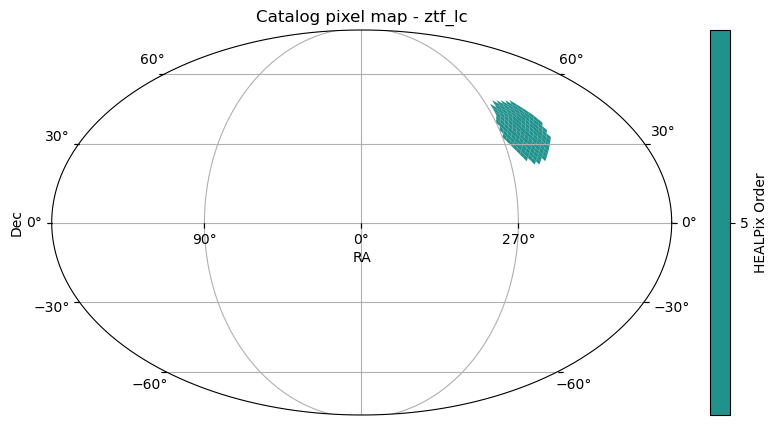

In [3]:
ztf_objects = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/ztf_dr22",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=40000, fine=True),
)
ztf_objects = ztf_objects.nest_lists(
    list_columns=["hmjd", "mag", "magerr", "clrcoeff", "catflags"],
    name="lc",  # name to give the resulting nested column
)
filtered_catalog = ztf_objects.query("filterid == 2")
filtered_catalog = filtered_catalog.query("lc.catflags == 0")

# Using map_partitions to drop rows with NaN in lc.mag
filtered_catalog = filtered_catalog.map_partitions(lambda df: df.dropna(subset=["lc.mag"]))

def median_mag(row):
    return np.median(row["lc.mag"])
    # return {"median_mag": np.median(row["lc.mag"])}


catalog_w_features = filtered_catalog.map_rows(
    median_mag,  # our user-defined function
    columns=["lc.mag"],  # names of the column(s) to pass to the function
    output_names=["median_mag"],  # name(s) of the new column(s)
    meta={"median_mag": float},  # for Dask: describe the type of the output
    append_columns=True,
)
catalog_w_features = catalog_w_features.query("median_mag < 16")

def count_points(pts):
    # Asked to count `lc`, this will add a column called `n_lc`
    return count_nested(pts, "lc")


catalog_w_features = catalog_w_features.map_partitions(count_points)
catalog_w_features = catalog_w_features.query("n_lc >= 10")

def dropna_lc(nf):
    return nf.dropna(on_nested="lc")
catalog_w_features = catalog_w_features.map_partitions(dropna_lc)

def extract_period(row):
    time = row["lc.hmjd"]
    mag = row["lc.mag"]
    error = row["lc.magerr"]
    ls = LombScargle(time, mag, error)
    freq, power = ls.autopower()
    argmax = np.argmax(power)
    period = 1.0 / freq[argmax]
    false_alarm_prob = ls.false_alarm_probability(power[argmax])
    return {"period": period, "false_alarm_prob": false_alarm_prob}


catalog_w_features = catalog_w_features.map_rows(
    extract_period,
    # Column names specifying function arguments
    columns=["lc.hmjd", "lc.mag", "lc.magerr"],
    # Returned data type shape
    meta={"period": float, "false_alarm_prob": float},
    append_columns=True,
)
periodic_catalog = catalog_w_features.query("false_alarm_prob < 1e-10 and 1.5 < period < 9.5")
periodic_catalog.plot_pixels()
periodic_catalog

## Compute

In [ ]:
%%time
periodic_df = periodic_catalog.compute()
periodic_df

## Stream

In [4]:
#client.restart()
periodic_stream = CatalogStream(periodic_catalog, partitions_per_chunk=24, shuffle=False)

In [5]:
%%time
for i,chunk in enumerate(periodic_stream):
    print(i)

/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/l

0


/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
2026-04-08 11:09:57,628 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 10.53 GiB -- Worker memory limit: 13.04 GiB
2026-04-08 11:09:57,827 - distributed.worker.memory - WARNING - 

1


/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/l

...

/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/l

3


/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/astro/users/smcampos/.conda/envs/lsdb_v06/l

4
5
CPU times: user 24.9 s, sys: 3.56 s, total: 28.4 s
Wall time: 12min 24s


/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/dask/_task_spec.py:768: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return self.func(*new_argspec)
